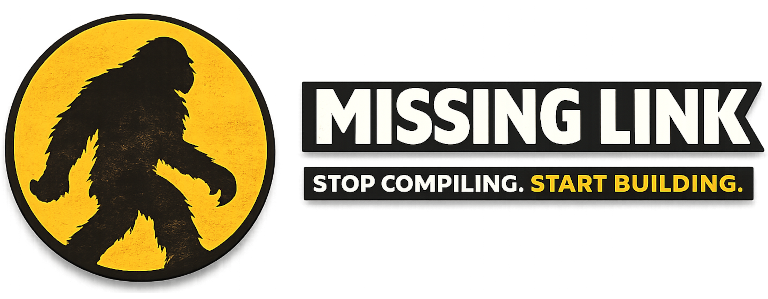

<div style="text-align:center;">
  
  <div style="margin-top:12px; font-size:16px;">
    <b>MissingLink Pre-Built Optimized A100 Colab Python wheels</b><br/>
    ZImage Image Generation Notebook, configuration time savings and out of the box compatibility with default A100 and L4 colab stacks.
  </div>
</div>

The *ZImage Image Generation MissingLink Notebook* lets you **Generate Beautiful 2D Images from text or image and text** ZImage is one of latest state of the art open source image generation models.

This notebook is designed to get you up and running in colab with zero configuration and zero headaches so you don't waste time and money on your A100 compiling and optimizing dependencies.

1. [Get a Token](https://www.missinglink.build/pricing.html) by signing up for the free trial or purchase a bundle at https://www.missinglink.build this will let you download the optimized A100 Colab wheels. **Replace the ****** text with your token in the cell below.** ( see [Additional Purchase Options](https://www.missinglink.build/pricing.html)

2. **Connect to L4 or A100 Runtime ( Top Right of Colab UI )** you will need to buy credits to run these instances [Buy Colab Credits](https://colab.research.google.com/signup?utm_source=resource_tab&utm_medium=link&utm_campaign=payg_learn_more)

3. Click '**Run All**'

4. Generate an image!

**UI Coming Soon

*Don't waste your time worrying about configuration or waiting for compilation!*

In [1]:
import os
#MACHINE = "l4" ir "a100"
os.environ['MISSING_LINK_TOKEN'] = "*******************"
TOKEN = os.environ['MISSING_LINK_TOKEN']
!pip install --no-deps "https://{TOKEN}@missinglink.build/wheel/flash_attn-2.7.3-cp312-cp312-linux_x86_64.whl"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.5/406.5 MB 2.2 MB/s eta 0:00:00


Generate an Image from Text with ZImage and Flash Attention 2.7.3 Painlessly in colab!

In [1]:
import os, torch
from packaging import version
import importlib

# 2) Sanity check: flash-attn import
import flash_attn
print("flash-attn:", flash_attn.__version__)
from diffusers import ZImagePipeline

dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float16
pipe = ZImagePipeline.from_pretrained("Tongyi-MAI/Z-Image-Turbo", torch_dtype=dtype)
pipe.to("cuda")
backend_set = False
try:
    pipe.transformer.set_attention_backend("flash")
    backend_set = True
    print("Using attention backend: flash (FlashAttention-2)")
except Exception as e:
    print("FA3 backend not set:", repr(e))
pipe.transformer.compile()

flash-attn: 2.7.3


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Attention backends are an experimental feature and the API may be subject to change.


Using attention backend: flash (FlashAttention-2)


Change the prompt and generate any image you can think of!

  0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/variables/functions.py:2056: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS="+dynamo" for a DEBUG stack trace.
  torch._dynamo.utils.warn_once(msg)
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:2156: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0224 23:48:28.633000 22057 torch/_inductor/utils.py:1679] [4/0] Not enough SMs to use max_autotune_gemm mode


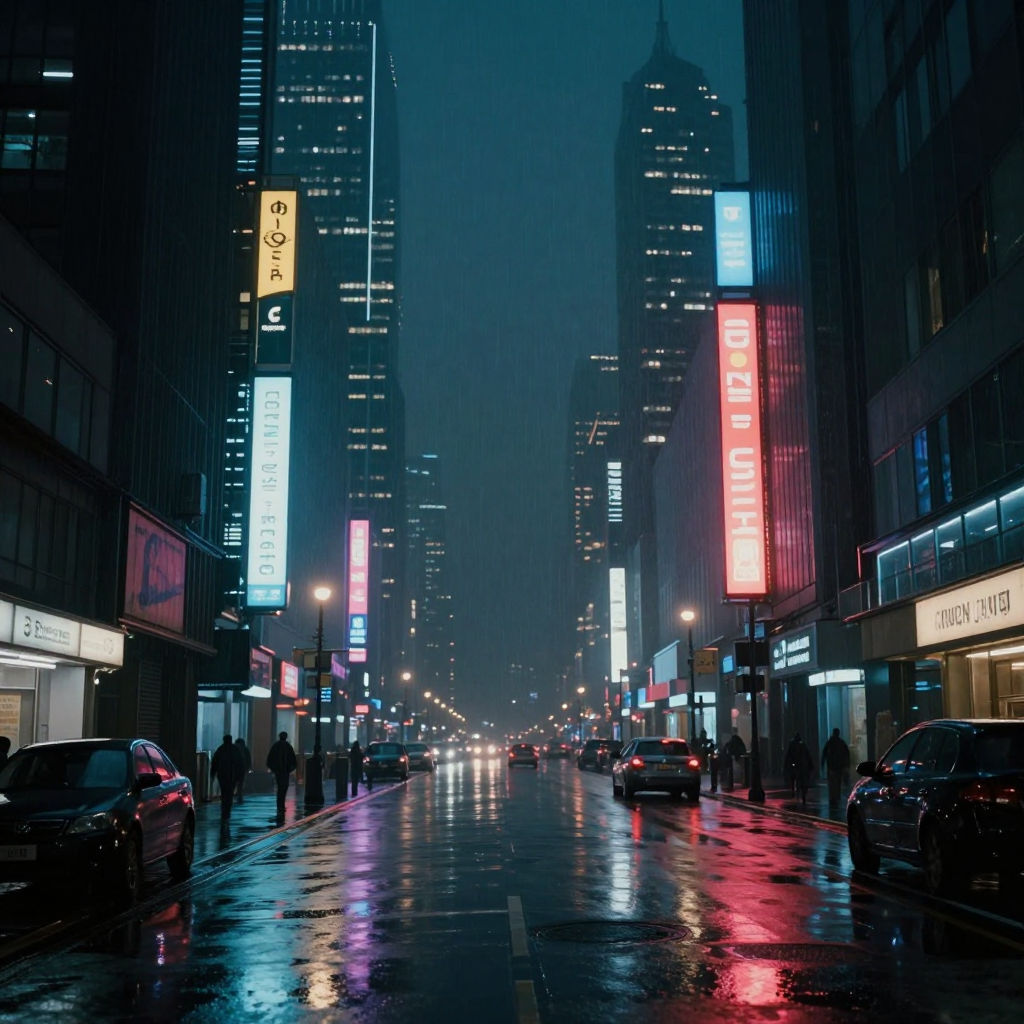

Saved: zimage_flashattn_283.png


In [2]:
prompt = "A cinematic photo of a futuristic neon city at night, ultra-detailed, 35mm, rain, reflections, moody lighting"
g = torch.Generator("cuda").manual_seed(42)

image = pipe(
    prompt,
    height=1024,
    width=1024,
    num_inference_steps=9,
    guidance_scale=0.0,
    generator=g,
).images[0]

display(image)
image.save("zimage_flashattn_283.png")
print("Saved: zimage_flashattn_283.png")